# 04 - Univariate Analysis

## Dataset: Telco Customer Churn

Univariate analysis is the analysis of a single variable at a time.

It helps us understand the distribution, central tendency, spread, and frequency of individual variables.

In this notebook, we will analyze:

- Numerical Variables
- Categorical Variables

We will use statistical measures and visualizations to understand the important variables in the dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Numerical Variable Analysis

Numerical variables contain quantitative values.

In the Telco Customer Churn dataset, important numerical variables include:

- SeniorCitizen
- tenure
- MonthlyCharges
- TotalCharges

`TotalCharges` is currently stored as an object, so it needs to be converted into a numerical format before performing numerical analysis.

In [3]:
# Convert TotalCharges to numeric

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check numerical columns

numerical_columns = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

df[numerical_columns].dtypes

,0
SeniorCitizen,int64
tenure,int64
MonthlyCharges,float64
TotalCharges,float64


## 2. Mean

The mean is the arithmetic average of a numerical variable.

It is calculated by adding all values and dividing the result by the number of observations.

Mean helps us understand the central tendency of the data.

In [4]:
# Calculate mean

df[numerical_columns].mean()

,0
SeniorCitizen,0.162147
tenure,32.371149
MonthlyCharges,64.761692
TotalCharges,2283.300441


## 3. Median

The median is the middle value when observations are arranged in ascending or descending order.

Median is less affected by extreme values than the mean.

In [5]:
# Calculate median

df[numerical_columns].median()

,0
SeniorCitizen,0.000
tenure,29.000
MonthlyCharges,70.350
TotalCharges,1397.475


## 4. Mode

The mode is the most frequently occurring value in a variable.

It can be useful for understanding the most common value in a dataset.

In [6]:
# Calculate mode

df[numerical_columns].mode()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,20.05,20.2


## 5. Minimum and Maximum

The minimum represents the smallest value and the maximum represents the largest value in a variable.

They help us understand the overall range of the data.

In [7]:
# Minimum values

print("Minimum:")
print(df[numerical_columns].min())

print("\nMaximum:")
print(df[numerical_columns].max())

Minimum:
SeniorCitizen      0.00
tenure             0.00
MonthlyCharges    18.25
TotalCharges      18.80
dtype: float64

Maximum:
SeniorCitizen        1.00
tenure              72.00
MonthlyCharges     118.75
TotalCharges      8684.80
dtype: float64


## 6. Range

Range is the difference between the maximum and minimum values.

Range = Maximum - Minimum

It provides a simple measure of how widely the values are spread.

In [8]:
# Calculate range

data_range = df[numerical_columns].max() - df[numerical_columns].min()

data_range

,0
SeniorCitizen,1.0
tenure,72.0
MonthlyCharges,100.5
TotalCharges,8666.0


## 7. Variance

Variance measures how far the observations are spread from their mean.

A higher variance indicates greater variability in the data.

In [9]:
# Calculate variance

df[numerical_columns].var()

,0
SeniorCitizen,1.358745e-01
tenure,6.031681e+02
MonthlyCharges,9.054109e+02
TotalCharges,5.138252e+06


## 8. Standard Deviation

Standard deviation measures the spread of values around the mean.

It is the square root of variance and is expressed in the same units as the original variable.

In [10]:
# Calculate standard deviation

df[numerical_columns].std()

,0
SeniorCitizen,0.368612
tenure,24.559481
MonthlyCharges,30.090047
TotalCharges,2266.771362


## 9. Quartiles

Quartiles divide ordered data into four parts.

- Q1 = 25th percentile
- Q2 = 50th percentile (Median)
- Q3 = 75th percentile

Quartiles help us understand the distribution and spread of numerical data.

In [11]:
# Calculate quartiles

df[numerical_columns].quantile([0.25, 0.50, 0.75])

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0.25,0.0,9.0,35.50,401.4500
0.50,0.0,29.0,70.35,1397.4750
0.75,0.0,55.0,89.85,3794.7375


## 10. Percentiles

A percentile indicates the value below which a given percentage of observations falls.

For example, the 90th percentile represents the value below which approximately 90% of observations fall.

In [12]:
# Calculate selected percentiles

df[numerical_columns].quantile([0.10, 0.25, 0.50, 0.75, 0.90])

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0.10,0.0,2.0,20.05,84.6000
0.25,0.0,9.0,35.50,401.4500
0.50,0.0,29.0,70.35,1397.4750
0.75,0.0,55.0,89.85,3794.7375
0.90,1.0,69.0,102.60,5976.6400


## 11. Skewness

Skewness measures the asymmetry of a distribution.

- Positive skewness indicates a longer right tail.
- Negative skewness indicates a longer left tail.
- A value close to zero indicates a relatively symmetric distribution.

In [13]:
# Calculate skewness

df[numerical_columns].skew()

,0
SeniorCitizen,1.833633
tenure,0.239540
MonthlyCharges,-0.220524
TotalCharges,0.961642


## 12. Kurtosis

Kurtosis describes the shape of the tails of a distribution and helps identify whether a distribution has relatively heavy or light tails compared with a normal distribution.

It can provide information about the presence of extreme values.

## 13. Histogram

A histogram shows the frequency distribution of a numerical variable.

It helps us understand:

- Distribution
- Concentration of values
- Spread
- Possible skewness
- Possible unusual values

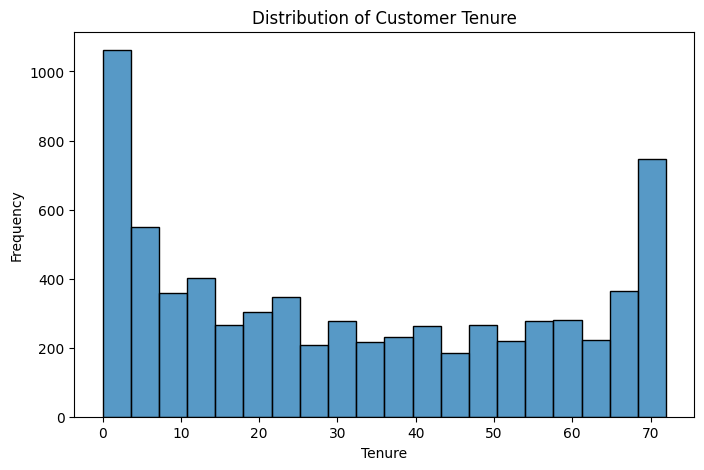

In [14]:
# Histogram of tenure

plt.figure(figsize=(8, 5))

sns.histplot(df["tenure"].dropna(), bins=20, kde=False)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.show()

## 14. KDE / Density Plot

A KDE (Kernel Density Estimate) plot provides a smooth representation of the distribution of a numerical variable.

It helps us understand the shape of the distribution.

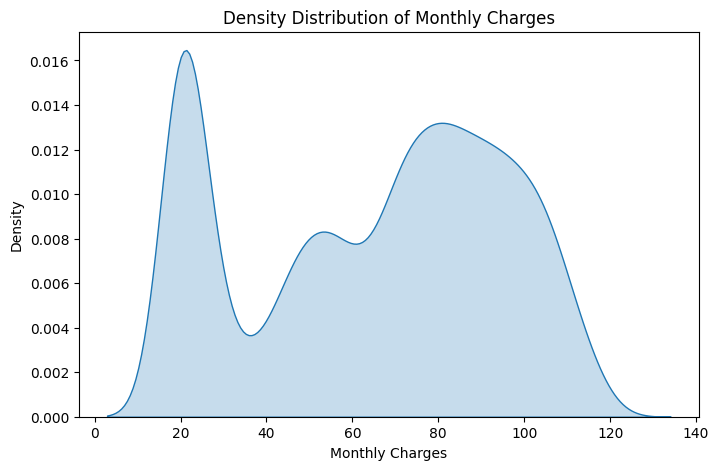

In [15]:
# KDE plot of MonthlyCharges

plt.figure(figsize=(8, 5))

sns.kdeplot(df["MonthlyCharges"].dropna(), fill=True)

plt.title("Density Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.show()

## 15. Box Plot

A box plot displays the distribution of a numerical variable using:

- Minimum
- Q1
- Median
- Q3
- Maximum

It is also useful for identifying potential outliers.

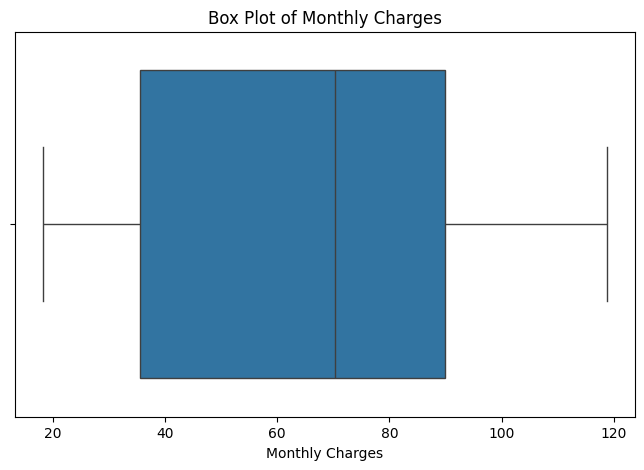

In [16]:
# Box plot of MonthlyCharges

plt.figure(figsize=(8, 5))

sns.boxplot(x=df["MonthlyCharges"])

plt.title("Box Plot of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.show()

## 16. Categorical Variable Analysis

Categorical variables contain categories or labels instead of continuous numerical measurements.

Examples in this dataset include:

- Gender
- Partner
- Dependents
- InternetService
- Contract
- PaymentMethod
- Churn

We will analyze their frequency, unique values, value counts, and percentage distribution.

## 17. Unique Values

The `nunique()` method tells us how many unique categories are present in each categorical variable.

In [17]:
categorical_columns = df.select_dtypes(include="object").columns

df[categorical_columns].nunique()

,0
customerID,7043
gender,2
Partner,2
Dependents,2
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3
DeviceProtection,3


## 18. Value Counts

The `value_counts()` method counts the number of observations belonging to each category.

In [18]:
# Value counts for Contract

df["Contract"].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


## 19. Percentage Distribution

Percentage distribution shows the proportion of observations belonging to each category.

It helps us compare categories regardless of the total number of observations.

In [19]:
# Percentage distribution of Contract

df["Contract"].value_counts(normalize=True) * 100

,proportion
Contract,
Month-to-month,55.019168
Two year,24.066449
One year,20.914383


## 20. Bar Chart

A bar chart represents the frequency of different categories.

It is useful for comparing categorical variables.

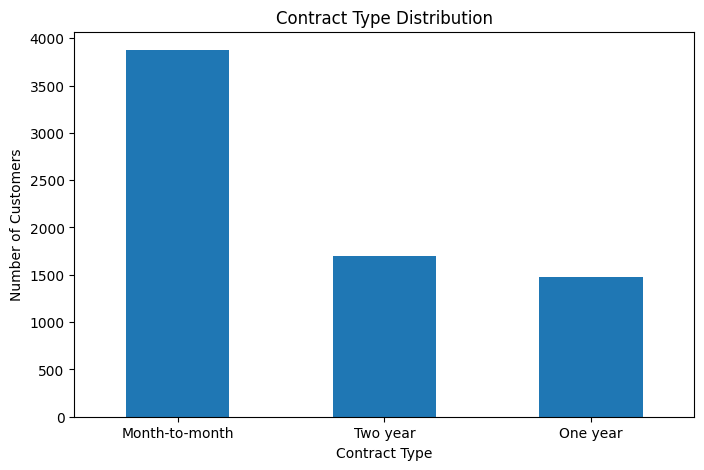

In [20]:
# Bar chart of Contract

plt.figure(figsize=(8, 5))

df["Contract"].value_counts().plot(kind="bar")

plt.title("Contract Type Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

## 21. Count Plot

A count plot displays the number of observations in each category.

It is particularly useful for quickly understanding categorical variable distributions.

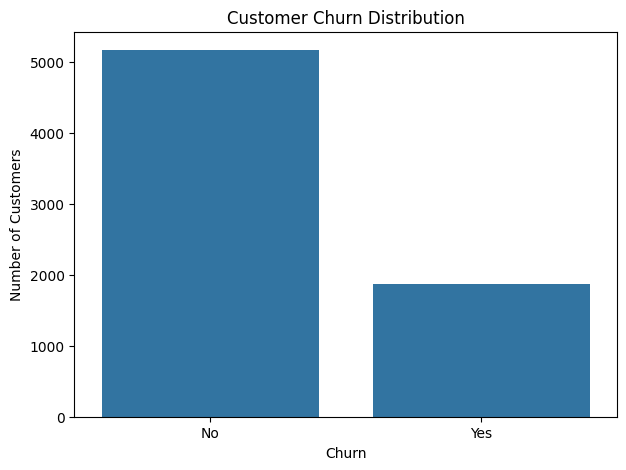

In [21]:
# Count plot of Churn

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## 22. Pie Chart

A pie chart shows the percentage contribution of different categories.

It can be useful when there are only a small number of categories.

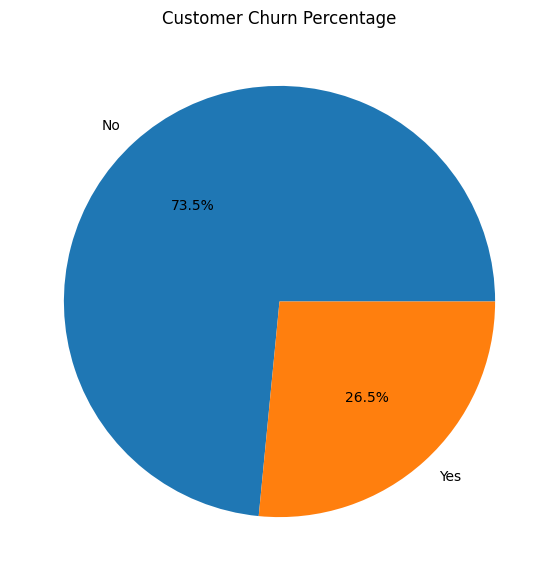

In [22]:
# Pie chart of Churn

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7, 7)
)

plt.title("Customer Churn Percentage")
plt.ylabel("")
plt.show()

## 23. Findings

### Numerical Variables

- `tenure` shows how long customers have stayed with the company.
- `MonthlyCharges` shows the monthly amount charged to customers.
- `TotalCharges` represents the total amount charged over the customer's tenure.
- Mean and median help understand the central tendency.
- Standard deviation and variance describe the spread of numerical variables.
- Quartiles and percentiles help understand the distribution.
- Skewness helps identify asymmetry in the distribution.
- Box plots can help identify potential outliers.

### Categorical Variables

- `Contract` shows the distribution of different contract types.
- `InternetService` shows the types of internet services used by customers.
- `PaymentMethod` shows how customers pay for the service.
- `Churn` shows the distribution of customers who stayed and customers who left.

These findings help us understand individual variables before moving to bivariate and multivariate analysis.

# Conclusion

Univariate analysis helps us understand one variable at a time.

Statistical measures provide numerical summaries, while visualizations help us understand distributions and patterns.

The analysis performed in this notebook provides a foundation for further exploratory analysis, including Bivariate Analysis.